<a href="https://colab.research.google.com/github/Blarg2134/MuhammudElsell_INFO4670_Fall2026/blob/main/Week_3_Assignment_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 3 · Guided Notebook — Making Sense of Data through Visualization
**INFO 4670 · Data Analysis and Knowledge Discovery**

This is where the coding starts. Every figure on the Week 3 slides was drawn here, from the Northgate files. Open this notebook **beside the slides** and run it cell by cell — then change things and re-run to see what happens.

**Before you start:** get the three Northgate CSVs into this notebook — the next cell gives you two ways (read from Drive, or drag-and-drop upload).

**The one idea to hold onto:** every chart in this notebook is the *same five lines*. Only the middle line — the one that draws the plot — and the labels change.

> Columns used below: from `student_records` — `commute_miles`, `final_gpa`, `major`, `work_hours_per_week`, `age`, `housing`; from `weekly_activity` — `student_id`, `week`, `minutes_active`. If a cell raises a `KeyError`, check the spelling against `students.info()`.

## Setup

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Northgate house style — keeps this notebook's charts looking like the slides
NAVY = "#22303A"
RUST = "#C0562F"
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"]   = (8, 5)
plt.rcParams["axes.titlesize"]   = 13
plt.rcParams["axes.titleweight"] = "bold"

## Load the data
Pick an option in the cell below, run it, then `.head()` / `.info()` — *look before you plot*.

In [5]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
# ============================================================
# STEP 1 — GET THE DATA. Pick ONE option, then run this cell.
# ============================================================
import pandas as pd
DATA_DIR = "."   # OPTION 2 (default) · drag the 3 CSVs into the file panel on the left

# OPTION 1 · read the files straight from Google Drive.
# To use this instead, uncomment the three lines below and edit the path
# so it points at the folder that holds your CSVs:
#from google.colab import drive
#drive.mount("/content/drive")
DATA_DIR = "/content/sample_data"

# ---------- load (works for either option) ----------
import os
students = pd.read_csv(os.path.join(DATA_DIR, "student_records.csv"))
weekly   = pd.read_csv(os.path.join(DATA_DIR, "weekly_activity.csv"))
courses = pd.read_csv(os.path.join(DATA_DIR, "course_enrollments.csv"))  # used in a later week

students.head()

,student_id,major,age,housing,commute_miles,work_hours_per_week,advisor_meetings,credits_attempted,final_gpa,study_hours_reported,enrollment_date,dropped_out
0,NU-101508,Data Science,27,Off-Campus,7.6,15,1,81,1.86,NaN,2023-09-13,1
1,NU-102438,Learning Technologies,25,With Family,14.3,35,1,100,2.06,9.5,2023-10-19,0
2,NU-102385,Learning Technologies,26,With Family,3.4,18,9,77,3.41,19.1,11/16/2022,0
3,NU-100767,Cyber Security,22,On-Campus,23.7,40,1,65,1.73,8.1,2024-05-03,0
4,NU-106054,Information Technology,21,Off-Campus,2.3,20,4,59,2.37,6.6,10/24/2022,0


In [7]:
# Always look before you plot: how many rows, which columns, what types?
students.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2027 entries, 0 to 2026
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   student_id            2027 non-null   object 
 1   major                 2027 non-null   object 
 2   age                   2027 non-null   int64  
 3   housing               2027 non-null   object 
 4   commute_miles         2027 non-null   float64
 5   work_hours_per_week   2027 non-null   int64  
 6   advisor_meetings      2027 non-null   int64  
 7   credits_attempted     2027 non-null   int64  
 8   final_gpa             2027 non-null   float64
 9   study_hours_reported  1772 non-null   float64
 10  enrollment_date       2027 non-null   object 
 11  dropped_out           2027 non-null   int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 190.2+ KB


## Part 1 · The grammar of graphics
Every chart is a **mapping**: data columns → graphical attributes (x-axis, y-axis, color, geometry). Before you draw anything, name which column is *quantitative* and which is *categorical* — that decides which charts are even legal. No code here; just the idea the rest of the notebook runs on.

## Part 2 · One quantitative variable
Four views of a single number column: **histogram · density · box · violin**. Start with the histogram — it answers "what's typical, and how spread out?"

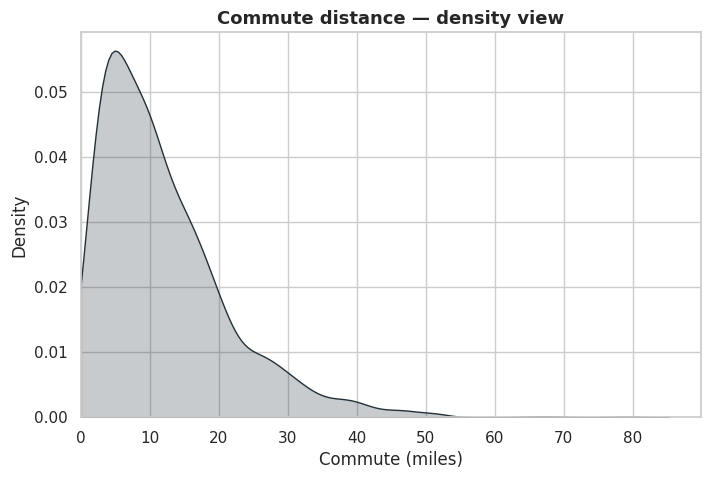

In [8]:
fig, ax = plt.subplots()
sns.kdeplot(data=students, x="commute_miles", color=NAVY, fill=True, ax=ax)
ax.set_title("Commute distance — density view")
ax.set_xlabel("Commute (miles)")
ax.set_ylabel("Density")
ax.set_xlim(left=0)
plt.show()

Quantitative:

Situation: This graph helps us understand the distance to campus to help evaulate transportation needs for our students.

Task: Visualizes the distribution of the commute in miles for the ranges in commute for ours students based on distance.

Action: this is a KDE plot with filled in shading where I set the axis to 0 so it doesn't show negative mileage data.

Result: The plot shows very clearly that between 0 and roughly 7 miles most of our students that go to the school live within this range. Although a sizable minority live very far from campus.

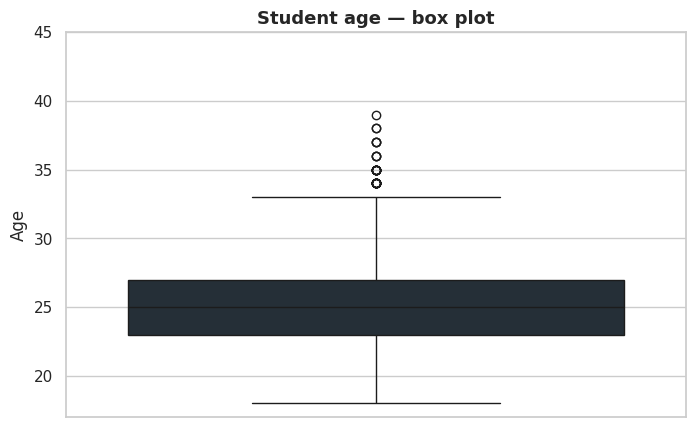

In [9]:
fig, ax = plt.subplots()
sns.boxplot(data=students, y="age", color=NAVY, ax=ax)
ax.set_title("Student age — box plot")
ax.set_ylabel("Age")
ax.set_ylim(17, 45)
plt.show()

Categorical:

Situation: This graph shows us the ages of our students with the defined average.

Task: Vizualizes the ages of our students so that we can better understand the needs and priorities of different age groups.

Action: This is a box plot with a defined median of 25, it especially show taht most of our students fall between the ages of 23-27 with our youngest being roughly 17.

Result: Our plot shows that the majority of our students are much younger and are between the ages of 23 and 27. While we have a small outlier in the ages being 39 and 17 at the limits each side of the graph. While also making sure that it doesn't show any ages out of bounds or unrealistic.

## Part 3 · One categorical variable
A categorical column has no range to bin — only categories to count. One **bar per category**, sorted by count.

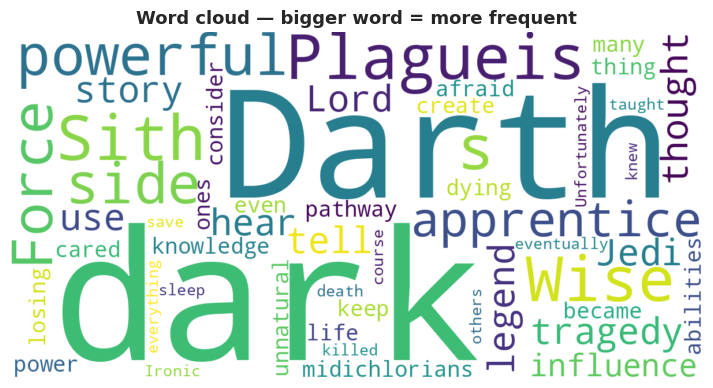

In [10]:
!pip install wordcloud -q          # installs the one extra library this chart needs
from wordcloud import WordCloud

# ---- Type or paste ANY text between the triple quotes, then re-run this cell. ----
# (Swap in advising notes, survey comments, an article — anything.)
text = """
"Did you ever hear the tragedy of Darth Plagueis The Wise? I thought not.
It’s not a story the Jedi would tell you. It’s a Sith legend.
Darth Plagueis was a Dark Lord of the Sith, so powerful and so wise he could use the Force to influence the midichlorians to create life…
He had such a knowledge of the dark side that he could even keep the ones he cared about from dying.
The dark side of the Force is a pathway to many abilities some consider to be unnatural.
He became so powerful… the only thing he was afraid of was losing his power, which eventually, of course, he did.
Unfortunately, he taught his apprentice everything he knew, then his apprentice killed him in his sleep.
Ironic. He could save others from death, but not himself."
"""

wc = WordCloud(width=1200, height=600, max_words=500, background_color="white").generate(text)
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.imshow(wc, interpolation="bilinear")
ax.axis("off")
ax.set_title("Word cloud — bigger word = more frequent")
plt.show()

Unstructured Chart Word Cloud:

Situation: This word cloud shows us that the larger the words appear the more frequent they are in the text.

Task: Vizualizes the frequency of all of the words within a text to see how frequently they appear.

Action: This generates a word cloud using Python word cloud which also removes regular stop words that are common in English like "so" or "and". And generates a cloud by the frequency of the words that are said in the text.

Result: This shows that the most common words used in this context are Dark, Sith, Plagueis, Wise, Force, and Powerful. From how often they appeared in the text.

## Part 4 · Two variables
Any single-variable plot becomes a two-variable plot when you split it by a category or pair it with a second number.

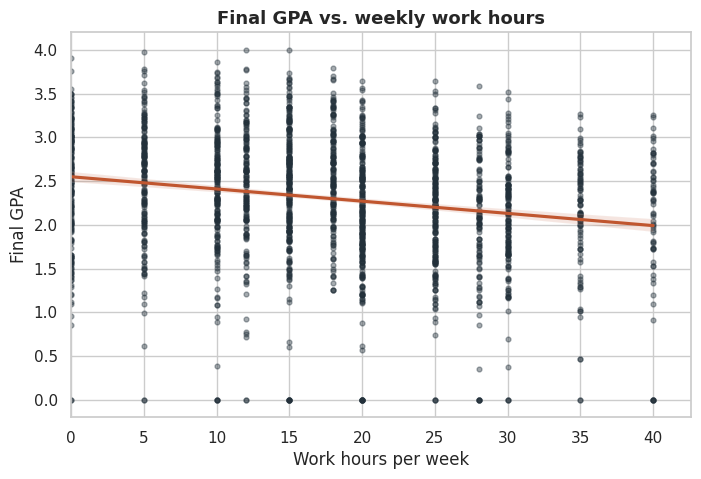

In [11]:
RUST = "#C0562F"

fig, ax = plt.subplots()
sns.regplot(data=students, x="work_hours_per_week", y="final_gpa",
            scatter_kws={"s": 12, "color": NAVY, "alpha": 0.4},
            line_kws={"color": RUST}, ax=ax)
ax.set_title("Final GPA vs. weekly work hours")
ax.set_xlabel("Work hours per week")
ax.set_ylabel("Final GPA")
ax.set_xlim(left=0)
plt.show()

Two Quantative Columns: Scatterplot with trend line


Situation: This allows us to track the commitment that working can do for students and whether or not it effects their GPA in a negative way the more they work.

Task: Knowing if working more hours can burden a student academically and stunt their potential growth.

Action: Created a scatterplot using regplot to show the trend line with working more hours to a students' GPA.

Result: This shows a very clear negative slope trend that working more hours for a student does indeed lower their GPA. But it is important to note the amount of variance across all working hour levels.

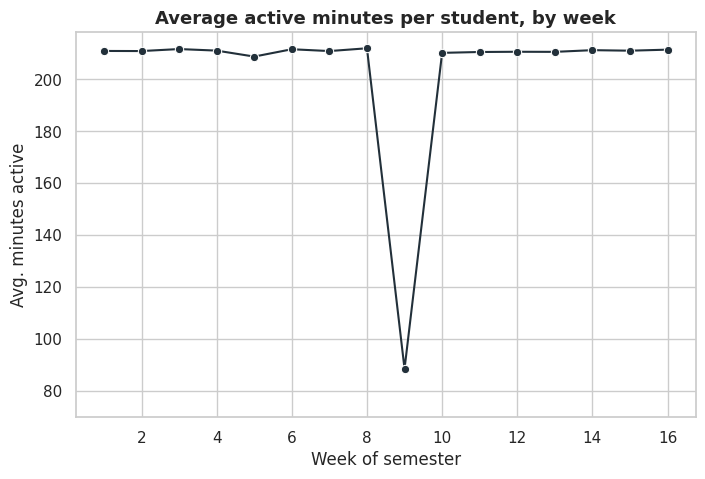

In [12]:
weekly_avg = weekly.groupby("week")["minutes_active"].mean().reset_index()
fig, ax = plt.subplots()
sns.lineplot(data=weekly_avg, x="week", y="minutes_active",
             color=NAVY, marker="o", ax=ax)
ax.set_title("Average active minutes per student, by week")
ax.set_xlabel("Week of semester")
ax.set_ylabel("Avg. minutes active")

ax.set_ylim(bottom=70)
plt.show()

Anything over time:

Situation: This chart shows the amount of student engagement over time for a semester on average.

Task: Vizualize the amount of time students spend per week active over the course of a semester.

Action: uses weekly.groupby to calculate active minutes on average for students and updates it weekly through the data points.

Result: This shows the clearest drop seems to be mid semester, likely in the spring due to spring break falling right around the 8 week mark. but I changed it so it doesn't show that it dropped to nearly nothing, only roughly 50% during the time period discussed before returning to regular levels of activity.

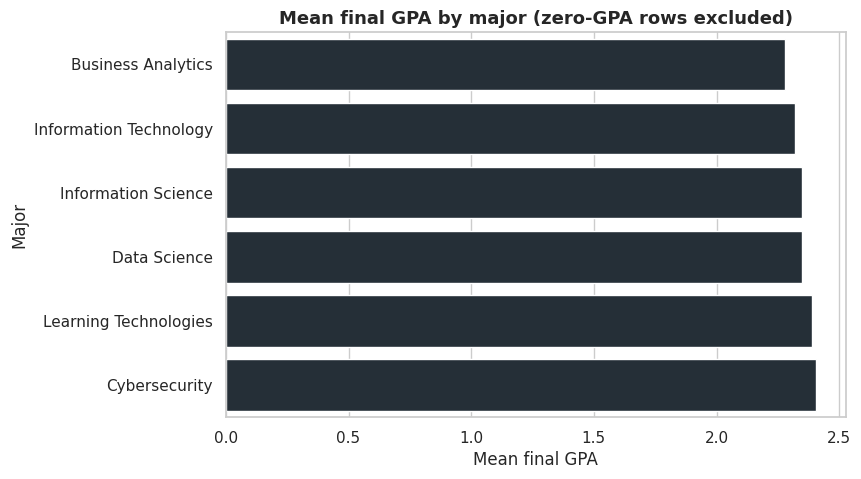

In [13]:
cleaned_majors = (
    students["major"]
    .astype(str)
    .str.strip()
    .str.replace(r"\s+", " ", regex=True))
major_map = {
    "Cyber Security": "Cybersecurity",
    "DataScience": "Data Science",
    "Info Technology": "Information Technology",
}
students["major_clean"] = cleaned_majors.replace(major_map)

means = (students[students["final_gpa"] > 0]              # set zero-GPA rows aside
         .groupby("major_clean")["final_gpa"].mean()
         .sort_values())
fig, ax = plt.subplots()
sns.barplot(x=means.values, y=means.index, color=NAVY, ax=ax)
ax.set_title("Mean final GPA by major (zero-GPA rows excluded)")
ax.set_xlabel("Mean final GPA")
ax.set_ylabel("Major")
plt.show()

Categorical vs Quantative:

Situation: Evaluating the performance that students have across multiple departments and whether different majors have differences in lower GPA's.

Task: Vizualizes and shows the average non-zero GPA that across different majors while fixing the incorrect strings within the dataset.  

Action: Merged duplicate entries of the same departments being discussed. For example Cyber Security and Cybersecurity with a 4.0 grading scale.

Result: the fixed chart showed that GPA's are relatively consistent across all of hte majors. This means that most of our schools department have little variation in the outperformance of others.

## Which chart? Let the attribute types decide
| You have | Reach for |
|---|---|
| One quantitative column | histogram · density · box · violin |
| One categorical column | sorted bar / column chart |
| Categorical + quantitative | labeled bars, or box/violin per category |
| Two quantitative columns | scatterplot with a trend line |
| Anything over time | line chart |
| Unstructured text | word cloud (first impressions only) |

Two questions, in order: **which charts are *possible* with these variables — and which is *appropriate* for this question?**

Part B:

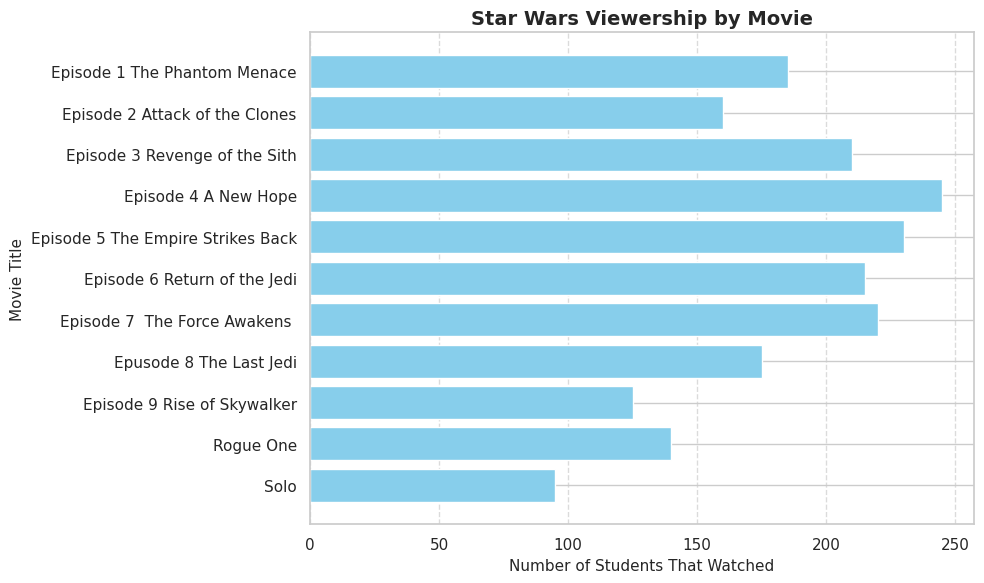

In [15]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv("Star_Wars_Survey.csv", header=1)
df.columns = df.columns.str.strip()
df = df[["Movie_Title", "Number_of_Students_Watched"]].dropna()
df["Number_of_Students_Watched"] = pd.to_numeric(
    df["Number_of_Students_Watched"]
)
plt.figure(figsize=(10, 6))
plt.barh(df["Movie_Title"], df["Number_of_Students_Watched"], color="skyblue")
plt.xlabel("Number of Students That Watched", fontsize=11)
plt.ylabel("Movie Title", fontsize=11)
plt.title("Star Wars Viewership by Movie", fontsize=14, fontweight="bold")
plt.gca().invert_yaxis()
plt.grid(axis="x", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

Categorical + Quantitative:

Situation: This analysis shows the number of students that have watched the movie series Star Wars

Task: the dataset had issues with not showing properly and most of what I was doing was just fixing and cleaning the data so it looked proper.

Action: I used Pandas to load the dataset, and transformed it by dropping out missing values and converted the survey counts to numeric data types using the pd.to_numeric

Result: This showed that the majority of the students that have watched star wars overwhelmingly watched a New Hope while barely any had watched Solo.

## Your turn → Assignment 1
Assignment 1 hands you Northgate columns and questions. For each one you'll **choose the chart, adapt one of the templates above, label it fully, and write a STAR story.** Every chart you need is already in this notebook — copy the closest cell, swap the column, and re-run.